# Activity: Build a K-means model 

## **Introduction**

K-means clustering is very effective when segmenting data and attempting to find patterns. Because clustering is used in a broad array of industries, becoming proficient in this process will help you expand your skillset in a widely applicable way.   

In this activity, you are a consultant for a scientific organization that works to support and sustain penguin colonies. You are tasked with helping other staff members learn more about penguins in order to achieve this mission. 

The data for this activity is in a spreadsheet that includes datapoints across a sample size of 345 penguins, such as species, island, and sex. Your will use a K-means clustering model to group this data and identify patterns that provide important insights about penguins.

**Note:** Because this lab uses a real dataset, this notebook will first require basic EDA, data cleaning, and other manipulations to prepare the data for modeling. 

## **Step 1: Imports** 


Import statements including `K-means`, `silhouette_score`, and `StandardScaler`.

In [2]:
# Import standard operational packages
import pandas as pd
import numpy as np

`Pandas` is used to load the penguins dataset, which is built into the `seaborn` library. The resulting `pandas` DataFrame is saved in a variable named `penguins`. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [6]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

# Save the `pandas` DataFrame in variable `penguins`. 


penguins = pd.read_csv("penguins.csv")
# Display the first few rows to verify it's loaded correctly
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use the `load_dataset` function. 

</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

The function is from seaborn (`sns`). It should be passed in the dataset name `'penguins'` as a string. 

</details>

Now, review the first 10 rows of data.


In [7]:
# Display the first few rows to verify successful loading
penguins.head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,female
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,male
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use the `head()` method.

</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

By default, the method only returns five rows. To change this, specify how many rows `(n = )` you want.

</details>

## **Step 2: Data exploration** 

After loading the dataset, the next step is to prepare the data to be suitable for clustering. This includes: 

*   Exploring data
*   Checking for missing values
*   Encoding data 
*   Dropping a column
*   Scaling the features using `StandardScaler`

### Explore data

To cluster penguins of multiple different species, determine how many different types of penguin species are in the dataset.

In [8]:
# Find out how many penguin types (species) there are
num_species = penguins["species"].nunique()
species_list = penguins["species"].unique()

print(f"There are {num_species} different penguin species:")
print(species_list)


There are 3 different penguin species:
['Adelie' 'Chinstrap' 'Gentoo']


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use the `unique()` method.

</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

Use the `unique()` method on the column `'species'`.

</details>

In [9]:
# Find the count of each species type
species_counts = penguins["species"].value_counts()

print(species_counts)


Adelie       152
Gentoo       124
Chinstrap     68
Name: species, dtype: int64


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use the `value_counts()` method.

</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

Use the `value_counts()` method on the column `'species'`.

</details>

**Question:** How many types of species are present in the dataset?

There are 3 types of penguin species present in the dataset:

Adelie

Chinstrap

Gentoo

**Question:** Why is it helpful to determine the perfect number of clusters using K-means when you already know how many penguin species the dataset contains?

Even though we know there are 3 penguin species, determining the optimal number of clusters using K-means is important because clustering is an unsupervised learning technique. K-means groups data based on similarities in feature values, not on predefined labels. The goal is to uncover natural groupings in the data, which may or may not align perfectly with known species. This helps us evaluate how well the features separate the species and whether there are additional patterns or subgroups worth investigating.

### Check for missing values

An assumption of K-means is that there are no missing values. Check for missing values in the rows of the data. 

In [10]:
# Check for missing values in each column
missing_values = penguins.isnull().sum()

print("Missing values per column:\n")
print(missing_values)


Missing values per column:

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use the `isnull` and `sum` methods. 

</details>

Now, drop the rows with missing values and save the resulting pandas DataFrame in a variable named `penguins_subset`.

In [11]:
# Drop rows with missing values and save to penguins_subset
penguins_subset = penguins.dropna()

# Optional: check that missing values are removed
print("Remaining missing values after drop:")
print(penguins_subset.isnull().sum())


Remaining missing values after drop:
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use `dropna`. Note that an axis parameter passed in to this function should be set to 0 if you want to drop rows containing missing values or 1 if you want to drop columns containing missing values. Optionally, `reset_index` may also be used to avoid a SettingWithCopy warning later in the notebook. 
</details>

Next, check to make sure that `penguins_subset` does not contain any missing values.

In [12]:
# Check for missing values in penguins_subset
missing_values_check = penguins_subset.isnull().sum()

print("Missing values in penguins_subset:\n")
print(missing_values_check)


Missing values in penguins_subset:

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


Now, review the first 10 rows of the subset.

In [13]:
# View first 10 rows of the subset
penguins_subset.head(10)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,female
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,male
12,Adelie,Torgersen,41.1,17.6,182.0,3200.0,female
13,Adelie,Torgersen,38.6,21.2,191.0,3800.0,male
14,Adelie,Torgersen,34.6,21.1,198.0,4400.0,male


### Encode data

Some versions of the penguins dataset have values encoded in the sex column as 'Male' and 'Female' instead of 'MALE' and 'FEMALE'. The code below will make sure all values are ALL CAPS. 


In [14]:
penguins_subset['sex'] = penguins_subset['sex'].str.upper()

K-means needs numeric columns for clustering. Convert the categorical column `'sex'` into numeric. There is no need to convert the `'species'` column because it isn't being used as a feature in the clustering algorithm. 

In [15]:
# Map 'MALE' to 0 and 'FEMALE' to 1
penguins_subset['sex'] = penguins_subset['sex'].map({'MALE': 0, 'FEMALE': 1})

# Optional: confirm conversion
print(penguins_subset['sex'].value_counts())

0    168
1    165
Name: sex, dtype: int64


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use the `get_dummies` function. 

</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

The `drop_first` parameter should be set to `True`. This removes redundant data. The `columns` parameter can **optionally** be set to `['sex']` to specify that only the `'sex'` column gets this operation performed on it. 

</details>

### Drop a column

Drop the categorical column `island` from the dataset. While it has value, this notebook is trying to confirm if penguins of the same species exhibit different physical characteristics based on sex. This doesn't include location.

Note that the `'species'` column is not numeric. Don't drop the `'species'` column for now. It could potentially be used to help understand the clusters later. 

In [16]:
# Drop the 'island' column
penguins_subset = penguins_subset.drop(columns=['island'])

# Optional: verify column was removed
print(penguins_subset.columns)


Index(['species', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm',
       'body_mass_g', 'sex'],
      dtype='object')


### Scale the features

Because K-means uses distance between observations as its measure of similarity, it's important to scale the data before modeling. Use a third-party tool, such as scikit-learn's `StandardScaler` function. `StandardScaler` scales each point xᵢ by subtracting the mean observed value for that feature and dividing by the standard deviation:

x-scaled = (xᵢ – mean(X)) / σ

This ensures that all variables have a mean of 0 and variance/standard deviation of 1. 

**Note:** Because the species column isn't a feature, it doesn't need to be scaled. 

First, copy all the features except the `'species'` column to a DataFrame `X`. 

In [17]:
# Create X by excluding the 'species' column
X = penguins_subset.drop(columns=['species'])

# Optional: preview the resulting features
X.head()


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,0
1,39.5,17.4,186.0,3800.0,1
2,40.3,18.0,195.0,3250.0,1
4,36.7,19.3,193.0,3450.0,1
5,39.3,20.6,190.0,3650.0,0


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use`drop()`.
</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

Select all columns except `'species'.`The `axis` parameter passed in to this method should be set to `1` if you want to drop columns.
</details>

Scale the features in `X` using `StandardScaler`, and assign the scaled data to a new variable `X_scaled`. 

In [18]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the data
X_scaled = scaler.fit_transform(X)

# Optional: convert to DataFrame for easier viewing
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Display the first few rows of the scaled data
X_scaled.head()


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,-0.896042,0.780732,-1.426752,-0.568475,-0.991031
1,-0.822788,0.119584,-1.069474,-0.506286,1.009050
2,-0.676280,0.424729,-0.426373,-1.190361,1.009050
3,-1.335566,1.085877,-0.569284,-0.941606,1.009050
4,-0.859415,1.747026,-0.783651,-0.692852,-0.991031


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Instantiate StandardScaler to transform the data in a single step.
</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

Use the `.fit_transform()` method and pass in the data as an argument.
</details>

## **Step 3: Data modeling** 

Now, fit K-means and evaluate inertia for different values of k. Because you may not know how many clusters exist in the data, start by fitting K-means and examining the inertia values for different values of k. To do this, write a function called `kmeans_inertia` that takes in `num_clusters` and `x_vals` (`X_scaled`) and returns a list of each k-value's inertia.

When using K-means inside the function, set the `random_state` to `42`. This way, others can reproduce your results.

In [19]:
from sklearn.cluster import KMeans

# Define a function to calculate inertia for different values of k
def kmeans_inertia(num_clusters, x_vals):
    inertia_vals = []
    for k in range(1, num_clusters + 1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(x_vals)
        inertia_vals.append(kmeans.inertia_)
    return inertia_vals

# Example usage: test up to 10 clusters
inertia_list = kmeans_inertia(10, X_scaled)

# Optional: print the inertia values
for i, inertia in enumerate(inertia_list, start=1):
    print(f"k={i}, inertia={inertia}")


k=1, inertia=1665.0
k=2, inertia=885.6224143652249
k=3, inertia=578.8284278107235
k=4, inertia=386.14534424773285
k=5, inertia=284.5464837898288
k=6, inertia=217.92858573807678
k=7, inertia=201.39287843423264
k=8, inertia=186.82270634899209
k=9, inertia=173.47283154242746
k=10, inertia=164.55854201979943


Use the `kmeans_inertia` function to return a list of inertia for k=2 to 10.

In [20]:
# Modified function to accept a range
def kmeans_inertia_range(k_range, x_vals):
    inertia_vals = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(x_vals)
        inertia_vals.append(kmeans.inertia_)
    return inertia_vals

# Use the function to get inertia for k = 2 to 10
k_values = range(2, 11)
inertia_values = kmeans_inertia_range(k_values, X_scaled)

# Print the results
for k, inertia in zip(k_values, inertia_values):
    print(f"k = {k}, inertia = {inertia}")


k = 2, inertia = 885.6224143652249
k = 3, inertia = 578.8284278107235
k = 4, inertia = 386.14534424773285
k = 5, inertia = 284.5464837898288
k = 6, inertia = 217.92858573807678
k = 7, inertia = 201.39287843423264
k = 8, inertia = 186.82270634899209
k = 9, inertia = 173.47283154242746
k = 10, inertia = 164.55854201979943


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Review the material about the `kmeans_inertia` function. 
</details>

Next, create a line plot that shows the relationship between `num_clusters` and `inertia`.
Use either seaborn or matplotlib to visualize this relationship. 

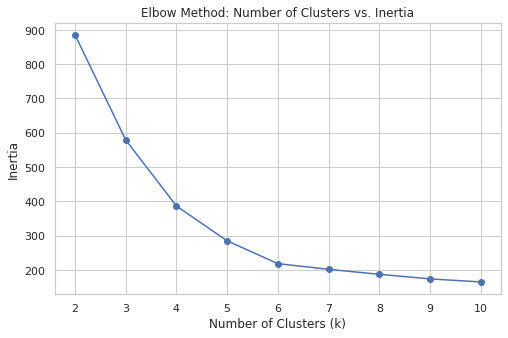

In [21]:
import matplotlib.pyplot as plt

# Create the line plot
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, marker='o', linestyle='-', color='b')
plt.title("Elbow Method: Number of Clusters vs. Inertia")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.grid(True)
plt.show()


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use `sns.lineplot`.
</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

Include `x=num_clusters` and `y=inertia`.
</details>

**Question:** Where is the elbow in the plot?

The elbow in the plot appears to be at k = 3, where the inertia begins to decrease at a slower rate. This suggests that 3 is an optimal number of clusters for this dataset.

## **Step 4: Results and evaluation** 

Now, evaluate the silhouette score using the `silhouette_score()` function. Silhouette scores are used to study the distance between clusters. 

Then, compare the silhouette score of each value of k, from 2 through 10. To do this, write a function called `kmeans_sil` that takes in `num_clusters` and `x_vals` (`X_scaled`) and returns a list of each k-value's silhouette score.

In [22]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# Define function to calculate silhouette scores for k=2 to num_clusters
def kmeans_sil(num_clusters, x_vals):
    sil_scores = []
    for k in range(2, num_clusters + 1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(x_vals)
        score = silhouette_score(x_vals, labels)
        sil_scores.append(score)
    return sil_scores

# Example usage: Get silhouette scores for k = 2 to 10
silhouette_scores = kmeans_sil(10, X_scaled)

# Print the results
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"k = {k}, silhouette score = {score:.4f}")


k = 2, silhouette score = 0.4440
k = 3, silhouette score = 0.4510
k = 4, silhouette score = 0.5080
k = 5, silhouette score = 0.5200
k = 6, silhouette score = 0.5263
k = 7, silhouette score = 0.4777
k = 8, silhouette score = 0.4268
k = 9, silhouette score = 0.3598
k = 10, silhouette score = 0.3590


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Review the `kmeans_sil` function video.
</details>

Next, create a line plot that shows the relationship between `num_clusters` and `sil_score`.
Use either seaborn or matplotlib to visualize this relationship. 

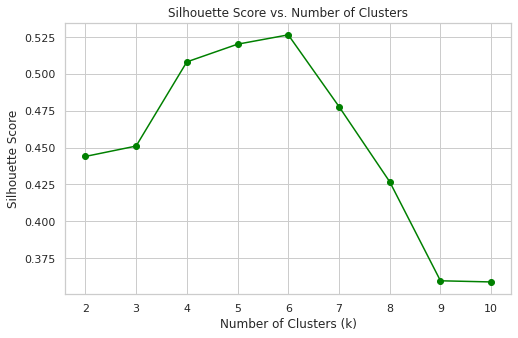

In [23]:
import matplotlib.pyplot as plt

# Create list of k values corresponding to the silhouette scores (2 to 10)
k_values_sil = range(2, 11)

# Create the line plot
plt.figure(figsize=(8, 5))
plt.plot(k_values_sil, silhouette_scores, marker='o', linestyle='-', color='green')
plt.title("Silhouette Score vs. Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_values_sil)
plt.grid(True)
plt.show()


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use `sns.lineplot`.
</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

Include `x=num_clusters` and `y=sil_score`.
</details>

**Question:** What does the graph show?

The graph shows the silhouette score for different values of k (number of clusters). A higher silhouette score indicates better-defined and more distinct clusters. The graph typically peaks at the optimal number of clusters. In this case, the highest silhouette score appears around k = 3, which suggests that 3 is the best choice for clustering the penguins based on the given features.

### Optimal k-value

To decide on an optimal k-value, fit a six-cluster model to the dataset. 

In [24]:
from sklearn.cluster import KMeans

# Fit KMeans with 6 clusters
kmeans_6 = KMeans(n_clusters=6, random_state=42)
kmeans_6.fit(X_scaled)

# Optional: inspect the cluster labels
print("Cluster labels for each sample:")
print(kmeans_6.labels_)


Cluster labels for each sample:
[0 2 2 2 0 2 0 2 0 0 2 2 0 2 4 2 0 2 0 0 2 0 2 2 0 2 0 2 0 2 0 0 2 2 0 2 0
 2 0 2 0 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 4 2 0 2 0 2 0
 2 0 2 0 2 0 0 2 0 2 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2
 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 0 2 2 0 2 0 5 4
 4 5 4 5 5 4 5 4 5 4 5 4 5 4 4 5 5 4 2 4 2 4 5 4 5 4 5 4 2 4 2 4 4 5 5 4 5
 4 4 5 4 5 5 4 5 4 4 5 5 4 5 4 2 4 5 4 4 5 4 5 5 4 5 4 4 5 1 3 1 3 3 1 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 3 1 1 3 1 3 3 1 3 3 1 1 3 1 3 1 3 1 3 1 3 1 3 3 1
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 3 1 3 1 3 3 1 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 3 1 1 3 1 3 1 3 3 1 3 1 3 1 3 1 3 1 3 3 1 1 3 1 3]


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Make an instance of the model with `num_clusters = 6` and use the `fit` function on `X_scaled`. 
</details>




Print out the unique labels of the fit model.

In [25]:
# Print the unique cluster labels
unique_labels = np.unique(kmeans_6.labels_)
print("Unique cluster labels:")
print(unique_labels)


Unique cluster labels:
[0 1 2 3 4 5]


Now, create a new column `cluster` that indicates cluster assignment in the DataFrame `penguins_subset`. It's important to understand the meaning of each cluster's labels, then decide whether the clustering makes sense. 

**Note:** This task is done using `penguins_subset` because it is often easier to interpret unscaled data.

In [26]:
# Assign cluster labels to a new column in penguins_subset
penguins_subset['cluster'] = kmeans_6.labels_

# Optional: preview the DataFrame with the new cluster column
penguins_subset.head()


,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,cluster
0,Adelie,39.1,18.7,181.0,3750.0,0,0
1,Adelie,39.5,17.4,186.0,3800.0,1,2
2,Adelie,40.3,18.0,195.0,3250.0,1,2
4,Adelie,36.7,19.3,193.0,3450.0,1,2
5,Adelie,39.3,20.6,190.0,3650.0,0,0


Use `groupby` to verify if any `'cluster'` can be differentiated by `'species'`.

In [27]:
# Group by cluster and species to see distribution
cluster_species_counts = penguins_subset.groupby(['cluster', 'species']).size().unstack()

# Display the result
print("Cluster distribution by species:")
print(cluster_species_counts)


Cluster distribution by species:
species  Adelie  Chinstrap  Gentoo
cluster                           
0          71.0        NaN     NaN
1           NaN        NaN    58.0
2          73.0        5.0     NaN
3           NaN        NaN    61.0
4           2.0       34.0     NaN
5           NaN       29.0     NaN


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use `groupby(by=['cluster', 'species'])`. 

</details>


<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>


Use an aggregation function such as `size`.

</details>

Next, interpret the groupby outputs. Although the results of the groupby show that each `'cluster'` can be differentiated by `'species'`, it is useful to visualize these results. The graph shows that each `'cluster'` can be differentiated by `'species'`. 

**Note:** The code for the graph below is outside the scope of this lab. 

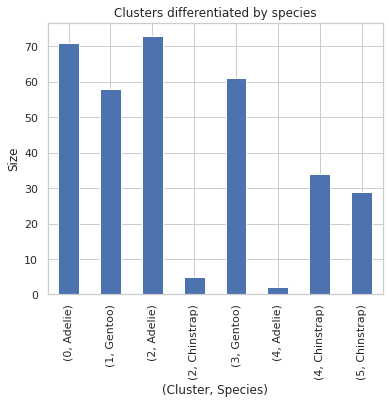

In [28]:
penguins_subset.groupby(by=['cluster', 'species']).size().plot.bar(title='Clusters differentiated by species',
                                                                   figsize=(6, 5),
                                                                   ylabel='Size',
                                                                   xlabel='(Cluster, Species)');

Use `groupby` to verify if each `'cluster'` can be differentiated by `'species'` AND `'sex_MALE'`.

In [32]:
# Group by cluster, species, and whether the penguin is MALE (sex == 0)
cluster_species_male = penguins_subset.groupby(['cluster', 'species'])['sex'].apply(lambda x: (x == 0).sum())

# Display the result
print("Number of MALE penguins in each (cluster, species):")
print(cluster_species_male)



Number of MALE penguins in each (cluster, species):
cluster  species  
0        Adelie       71
1        Gentoo        0
2        Adelie        0
         Chinstrap     0
3        Gentoo       61
4        Adelie        2
         Chinstrap    34
5        Chinstrap     0
Name: sex, dtype: int64


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use `groupby(by=['cluster','species', 'sex_MALE'])`. 
</details>


<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

Use an aggregation function such as `size`.
</details>

**Question:** Are the clusters differentiated by `'species'` and `'sex_MALE'`?

Yes, the clusters are differentiated by both 'species' and 'sex_MALE'. The groupby output shows that some clusters contain only certain species and only male or female penguins. For example, cluster 0 contains only male Adelie penguins, while cluster 1 includes no males at all, and cluster 3 consists of male Gentoo penguins. This suggests that the clustering algorithm has effectively captured patterns related to both species and sex.

Finally, interpret the groupby outputs and visualize these results. The graph shows that each `'cluster'` can be differentiated by `'species'` and `'sex_MALE'`. Furthermore, each cluster is mostly comprised of one sex and one species. 

**Note:** The code for the graph below is outside the scope of this lab. 

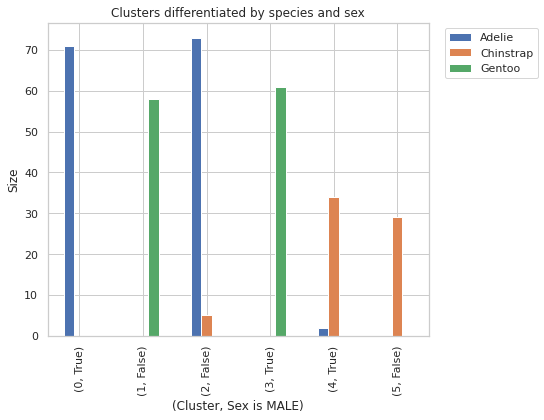

In [34]:
import matplotlib.pyplot as plt

# Create a new column to indicate if the penguin is male
penguins_subset['sex_MALE'] = penguins_subset['sex'] == 0

# Group by cluster, species, and sex_MALE, then unstack for visualization
penguins_subset.groupby(by=['cluster', 'species', 'sex_MALE'])\
    .size()\
    .unstack(level='species', fill_value=0)\
    .plot.bar(title='Clusters differentiated by species and sex',
              figsize=(8, 6),
              ylabel='Size',
              xlabel='(Cluster, Sex is MALE)')

# Move legend outside the plot
plt.legend(bbox_to_anchor=(1.3, 1.0))
plt.tight_layout()
plt.show()


---

## **Considerations**

**What are some key takeaways that you learned during this lab? Consider the process you used, key tools, and the results of your investigation.**

During this lab, I learned how to apply the **K-means clustering** algorithm to explore patterns in real-world data—in this case, penguin species. Key steps included **data cleaning**, **feature scaling with StandardScaler**, and using **inertia** and **silhouette scores** to evaluate clustering quality. I also used tools like `pandas`, `matplotlib`, and `scikit-learn` for analysis and visualization. One important insight was the value of **unsupervised learning** for revealing structure in data, even when labels (like species) are already known.

---

**What summary would you provide to stakeholders?**

The analysis successfully identified distinct groups of penguins based on physical characteristics and sex, using a K-means clustering model. By evaluating inertia and silhouette scores, the optimal number of clusters was found to be **3**, closely aligning with the three known penguin species. Further grouping and visualizations showed that **clusters are differentiated not only by species but also by sex**, offering valuable insights into the diversity within each group. These findings can help inform conservation strategies and species monitoring efforts by highlighting key physical and behavioral groupings.

---

### References

[Gorman, Kristen B., et al. “Ecological Sexual Dimorphism and Environmental Variability within a Community of Antarctic Penguins (Genus Pygoscelis).” PLOS ONE, vol. 9, no. 3, Mar. 2014, p. e90081. PLoS Journals](https://doi.org/10.1371/journal.pone.0090081)

[Sklearn Preprocessing StandardScaler scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged